<h1>Tarea 1. Analisis de Algoritmos <h1>
<h4>Autor: Miranda Sanchez Javier Leonardo<h4>
<h4>Matricula: 223215039<h4>


En este notebook se analizan experimentalmente tres algoritmos de ordenamiento <b>Insertion Sort</b>, <b>Selection Sort</b> y <b>Merge Sort</b>. El objetivo es estudiar su comportamiento en terminos de tiempo de ejecucion al aplicarlos sobre arreglos de longitud $n$

Con el fin de facilitar el trabajo, se implementaron funciones auxiliares que permiten generar las muestras de dados, medir los tiempos de ejecucion y graficar los resultados obtenidos

In [13]:
#Bibliotecas a utilizar.
import random
import time
import matplotlib.pyplot as plt
import math

<h1>Creacion de muestras.<h1>

In [ ]:
#Creacion de las muestras a utilizar para los algoritmos (MEJOR CASO).
def creacion_muestra_mejor_caso(n):
    n += 1
    muestra_mejor_caso = []

    for i in range(1, n):
        muestra_mejor_caso.append(i)
    
    return muestra_mejor_caso

#Creacion de las muestras a utilizar para los algoritmos (PEOR CASO).
def creacion_muestra_peor_caso(n):
    n += 1
    muestra_peor_caso = []

    for i in range(1, n):
        muestra_peor_caso.append(n - i)
    
    return muestra_peor_caso

#Creacion de las muestras a utilizar para los algoritmos (CASO PROMEDIO).
def creacion_muestras_caso_promedio(n):

    muestra_caso_promedio = []
    muestra_caso_promedio = random.sample(range(1,n + 1), n)

    return muestra_caso_promedio


<h1>Codificacion de algoritmos de ordenamiento.<h1>

In [15]:
#Codificacion del algoritmo INSERTION-SORT
def INSERTION_SORT(array):
    inicio = time.perf_counter()

    for j in range(1, len(array)):
        key = array[j]
        i = j - 1
        while i >= 0 and array[i] > key:
            array[i + 1] = array[i]
            i = i - 1
        array[i + 1] = key
    
    fin = time.perf_counter()
    tiempo = (fin - inicio) * 1000
    return array, tiempo

#Codificacion del aloritmo SELECTION-SORT
def SELECTION_SORT(array):
    inicio = time.perf_counter()

    for i in range(0, len(array) - 1):
        min_j = i
        min_x = array[i]
        for j in range (i + 1, len(array)):
            if (array[j] < min_x):
                min_j = j
                min_x = array[j]
        array[min_j] = array[i]
        array[i] = min_x
    

    fin = time.perf_counter()
    tiempo = (fin - inicio) * 1000
    return array, tiempo

#Codificacion del algoritmo MERGE-SORT
def MERGE_SORT(array):
    inicio = time.perf_counter()

    def merge_sort(array, p, r):
        if p < r:
            q = math.floor((p + r) / 2)
            merge_sort(array, p, q)
            merge_sort(array, q + 1,r)
            merge(array, p, q, r)

    def merge(A, p, q, r):
        L = A[p:q+1]+[float('inf')]
        R = A[q+1:r+1]+[float('inf')]
        i = 0
        j = 0
        for k in range(p, r + 1):

            if L[i] <= R[j]:
                A[k] = L[i]
                i += 1
            else:
                A[k] = R[j]
                j += 1

    merge_sort(array, 0, len(array) - 1)
    fin = time.perf_counter()
    tiempo = (fin - inicio) * 1000
    return array, tiempo
    


In [16]:
SELECTION_SORT([5,4,3,2,1])

([1, 2, 3, 4, 5], 0.007168999985651681)

<h1>Funcion para graficar el tiempo respecto a la longitud de n.<h1>

In [17]:
def graficar(tam, mejor, promedio, peor, algoritmo):

    plt.figure(figsize=(8,5))

    # Mejor caso
    plt.plot(tam, mejor, 'o-', label="Mejor caso")

    # Caso promedio
    plt.plot(tam, promedio, 'o-', label="Caso promedio")

    # Peor caso
    plt.plot(tam, peor, 'o-', label="Peor caso")

    plt.xlabel("Tamaño del array (n)")
    plt.ylabel("Tiempo (ms)")
    plt.title(f"Análisis de complejidad del algoritmo: {algoritmo}")

    plt.legend()
    plt.grid(True)

    plt.show()



<h1>Graficas de los algoritmos.<h1>

In [18]:
tam = []
tiem_mejor = []
tiem_prom = []
tiem_peor = []

for n in range(1, 11):

    size = n * 10
    tam.append(size)

    _, t_mejor = INSERTION_SORT(creacion_muestra_mejor_caso(size))
    _, t_peor = INSERTION_SORT(creacion_muestra_peor_caso(size))
    _, t_prom = INSERTION_SORT(creacion_muestras_caso_promedio(size))

    tiem_mejor.append(t_mejor)
    tiem_peor.append(t_peor)
    tiem_prom.append(t_prom)


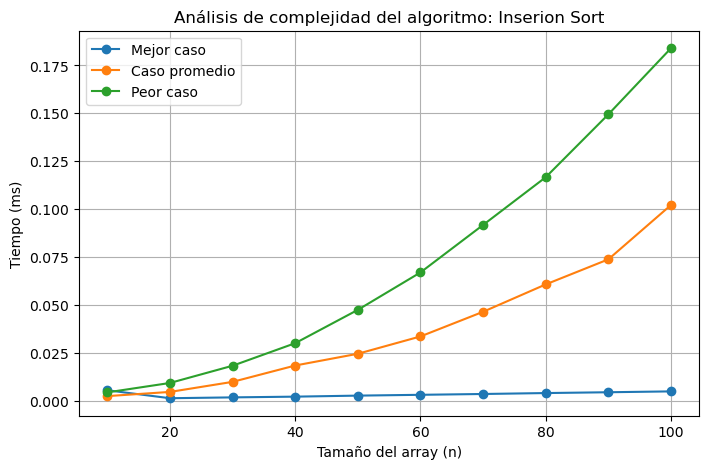

In [19]:
graficar(tam, tiem_mejor,tiem_prom, tiem_peor, "Inserion Sort")

In [20]:
tam = []
tiem_mejor = []
tiem_prom = []
tiem_peor = []

for n in range(1, 11):

    size = n * 10
    tam.append(size)

    _, t_mejor = SELECTION_SORT(creacion_muestra_mejor_caso(size))
    _, t_peor = SELECTION_SORT(creacion_muestra_peor_caso(size))
    _, t_prom = SELECTION_SORT(creacion_muestras_caso_promedio(size))

    tiem_mejor.append(t_mejor)
    tiem_peor.append(t_peor)
    tiem_prom.append(t_prom)

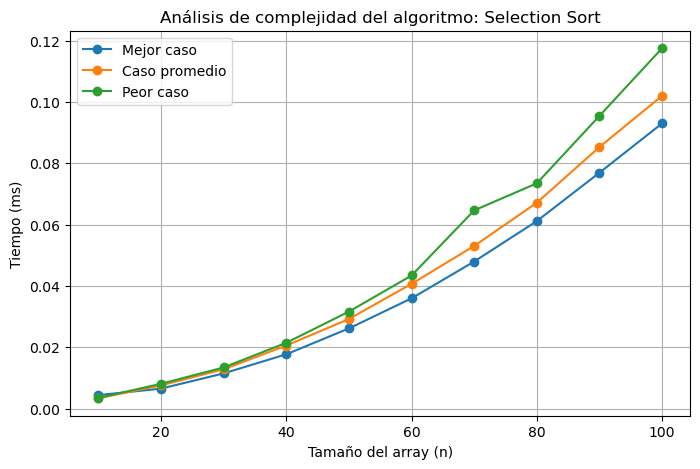

In [21]:
graficar(tam, tiem_mejor,tiem_prom, tiem_peor, "Selection Sort")

In [22]:
tam = []
tiem_mejor = []
tiem_prom = []
tiem_peor = []

for n in range(1, 11):

    size = n * 10
    tam.append(size)

    _, t_mejor = SELECTION_SORT(creacion_muestra_mejor_caso(size))
    _, t_peor = SELECTION_SORT(creacion_muestra_peor_caso(size))
    _, t_prom = SELECTION_SORT(creacion_muestras_caso_promedio(size))

    tiem_mejor.append(t_mejor)
    tiem_peor.append(t_peor)
    tiem_prom.append(t_prom)

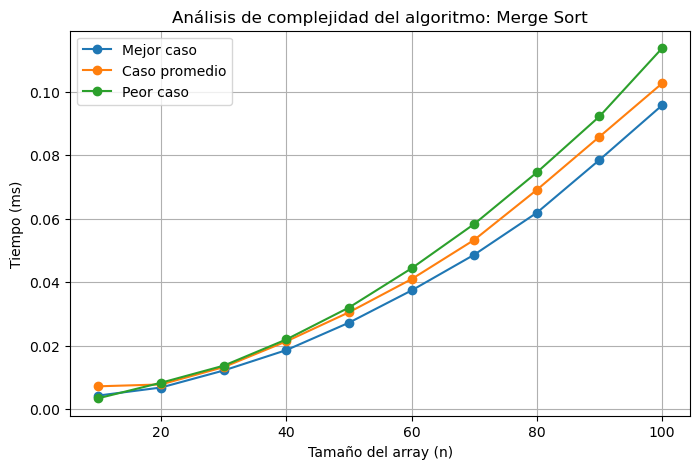

In [23]:
graficar(tam, tiem_mejor,tiem_prom, tiem_peor, "Merge Sort")